# 🗄️ PROJECT 3: SQL DATA ANALYSIS

##   Setup

We load our CSV into SQLite → Then query it with real SQL!

In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print(' Libraries imported!')

 Libraries imported!


##  Upload Your Cleaned CSV

In [ ]:
from google.colab import files

print(' Upload your Dataset_Cleaned_Project1.csv file:')
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f' Loaded: {len(df)} rows × {len(df.columns)} columns')
print(f'\nColumns: {list(df.columns)}')

 Upload your Dataset_Cleaned_Project1.csv file:


Saving Dataset_Cleaned_Project1.csv to Dataset_Cleaned_Project1.csv
 Loaded: 1200 rows × 14 columns

Columns: ['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


##  Load Data into SQLite Database

In [ ]:
# Create database connection
conn = sqlite3.connect('orders.db')

# Load CSV into SQL table named 'orders'
df.to_sql('orders', conn, if_exists='replace', index=False)

print(' Database created: orders.db')
print(' Table created: orders')
print(f' Rows loaded: {len(df)}')

# Helper function to run SQL and show results
def run_sql(query, show_rows=10):
    result = pd.read_sql_query(query, conn)
    print(f'\nRows returned: {len(result)}')
    print(result.head(show_rows).to_string(index=False))
    return result

print('\n run_sql() function ready!')
print('Usage: run_sql("YOUR SQL QUERY HERE")')

 Database created: orders.db
 Table created: orders
 Rows loaded: 1200

 run_sql() function ready!
Usage: run_sql("YOUR SQL QUERY HERE")


# QUERY 1: Basic SELECT

In [ ]:

print('QUERY 1: Basic SELECT - View the data')


query1 = """
SELECT *
FROM orders
LIMIT 10;
"""

print('SQL Query:')
print(query1)
print('Results:')
result1 = run_sql(query1, show_rows=10)

print('\n What this tells us:')
print('   We can see the first 10 orders in our database')
print('   This confirms data loaded correctly into SQL')

QUERY 1: Basic SELECT - View the data
SQL Query:

SELECT *
FROM orders
LIMIT 10;

Results:

Rows returned: 10
  OrderID       Date CustomerID Product  Quantity  UnitPrice ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart CouponCode ReferralSource  TotalPrice
ORD200000 2023-01-04     C72649 Monitor         5     570.62     928 Main St    Debit Card     Shipped    TRK37947903            7     Save10      Instagram     2853.10
ORD200001 2024-08-23     C75739   Phone         2     151.35     823 Main St        Online     Shipped    TRK91186779            3     Save10       Referral      302.70
ORD200002 2024-02-27     C81728  Tablet         5     550.68     512 Main St   Credit Card   Cancelled    TRK42903982            8   Freeship          Email     2753.40
ORD200003 2023-10-15     C33540   Chair         1     273.19     275 Main St    Debit Card    Returned    TRK62788070            5     Save10       Facebook      273.19
ORD200004 2025-05-08     C81840 Printer      

#  QUERY 2: COUNT - How many orders?

In [ ]:

print('QUERY 2: COUNT - Total orders')


query2 = """
SELECT
    COUNT(*) AS Total_Orders,
    COUNT(DISTINCT OrderID) AS Unique_Orders,
    COUNT(DISTINCT Product) AS Unique_Products,
    COUNT(DISTINCT PaymentMethod) AS Payment_Methods
FROM orders;
"""

print('SQL Query:')
print(query2)
print('Results:')
result2 = run_sql(query2)

print('\n Business Insight:')
print('   COUNT(*) gives us the scale of our business')
print('   DISTINCT = unique values only (no repeats)')

QUERY 2: COUNT - Total orders
SQL Query:

SELECT
    COUNT(*) AS Total_Orders,
    COUNT(DISTINCT OrderID) AS Unique_Orders,
    COUNT(DISTINCT Product) AS Unique_Products,
    COUNT(DISTINCT PaymentMethod) AS Payment_Methods
FROM orders;

Results:

Rows returned: 1
 Total_Orders  Unique_Orders  Unique_Products  Payment_Methods
         1200           1200                7                5

 Business Insight:
   COUNT(*) gives us the scale of our business
   DISTINCT = unique values only (no repeats)


#  QUERY 3: SUM & AVG - Revenue Analysis

In [ ]:

print('QUERY 3: SUM & AVG - Revenue Analysis')


query3 = """
SELECT
    ROUND(SUM(TotalPrice), 2)   AS Total_Revenue,
    ROUND(AVG(TotalPrice), 2)   AS Avg_Order_Value,
    ROUND(MIN(TotalPrice), 2)   AS Min_Order,
    ROUND(MAX(TotalPrice), 2)   AS Max_Order,
    ROUND(AVG(Quantity), 2)     AS Avg_Items_Per_Order
FROM orders;
"""

print('SQL Query:')
print(query3)
print('Results:')
result3 = run_sql(query3)

print('\n Business Insight:')
print('   ROUND() = Control decimal places (professional output)')
print('   MIN/MAX = Find range of order values')
print('   These 5 numbers summarize your entire business revenue!')

QUERY 3: SUM & AVG - Revenue Analysis
SQL Query:

SELECT
    ROUND(SUM(TotalPrice), 2)   AS Total_Revenue,
    ROUND(AVG(TotalPrice), 2)   AS Avg_Order_Value,
    ROUND(MIN(TotalPrice), 2)   AS Min_Order,
    ROUND(MAX(TotalPrice), 2)   AS Max_Order,
    ROUND(AVG(Quantity), 2)     AS Avg_Items_Per_Order
FROM orders;

Results:

Rows returned: 1
 Total_Revenue  Avg_Order_Value  Min_Order  Max_Order  Avg_Items_Per_Order
    1264761.96          1053.97      11.39     3456.4                 2.95

 Business Insight:
   ROUND() = Control decimal places (professional output)
   MIN/MAX = Find range of order values
   These 5 numbers summarize your entire business revenue!


#  QUERY 4: WHERE - Filter Orders

In [ ]:

print('QUERY 4: WHERE - High Value Orders (over $500)')


query4 = """
SELECT
    OrderID,
    Product,
    Quantity,
    TotalPrice,
    PaymentMethod,
    OrderStatus
FROM orders
WHERE TotalPrice > 500
ORDER BY TotalPrice DESC
LIMIT 15;
"""

print('SQL Query:')
print(query4)
print('Results (Top 15 high-value orders):')
result4 = run_sql(query4, show_rows=15)

# Count them
count_query = "SELECT COUNT(*) as High_Value_Count FROM orders WHERE TotalPrice > 500"
count_result = pd.read_sql_query(count_query, conn)
high_value_count = count_result['High_Value_Count'].values[0]
total = len(df)

print(f'\n Business Insight:')
print(f'   {high_value_count} orders are high-value (>${500})')
print(f'   That is {(high_value_count/total*100):.1f}% of all orders')
print(f'   These are your VIP customers worth targeting! ')

QUERY 4: WHERE - High Value Orders (over $500)
SQL Query:

SELECT
    OrderID,
    Product,
    Quantity,
    TotalPrice,
    PaymentMethod,
    OrderStatus
FROM orders
WHERE TotalPrice > 500
ORDER BY TotalPrice DESC
LIMIT 15;

Results (Top 15 high-value orders):

Rows returned: 15
  OrderID Product  Quantity  TotalPrice PaymentMethod OrderStatus
ORD200789  Tablet         5     3456.40        Online   Delivered
ORD201122 Monitor         5     3390.95        Online    Returned
ORD200632  Laptop         5     3390.80     Gift Card   Delivered
ORD200469   Chair         5     3384.90          Cash   Cancelled
ORD200328  Tablet         5     3370.20        Online   Cancelled
ORD200107 Printer         5     3353.75     Gift Card     Shipped
ORD200326  Laptop         5     3352.40     Gift Card    Returned
ORD201065 Printer         5     3334.00    Debit Card   Delivered
ORD201031   Phone         5     3322.55    Debit Card     Pending
ORD200463  Laptop         5     3313.90    Debit Card    

#  QUERY 5: GROUP BY - Sales by Product

QUERY 5: GROUP BY - Revenue by Product
SQL Query:

SELECT
    Product,
    COUNT(*)                      AS Total_Orders,
    ROUND(SUM(TotalPrice), 2)     AS Total_Revenue,
    ROUND(AVG(TotalPrice), 2)     AS Avg_Order_Value,
    ROUND(MIN(TotalPrice), 2)     AS Min_Order,
    ROUND(MAX(TotalPrice), 2)     AS Max_Order
FROM orders
GROUP BY Product
ORDER BY Total_Revenue DESC;

Results:

Rows returned: 7
Product  Total_Orders  Total_Revenue  Avg_Order_Value  Min_Order  Max_Order
  Chair           178      195620.11          1098.99      23.53    3384.90
Printer           181      195612.61          1080.73      30.44    3353.75
 Laptop           173      192126.56          1110.56      18.20    3390.80
 Tablet           179      186568.95          1042.28      17.24    3456.40
Monitor           163      175651.41          1077.62      24.48    3390.95
   Desk           170      167459.93           985.06      26.95    3194.00
  Phone           156      151722.39           972.58      

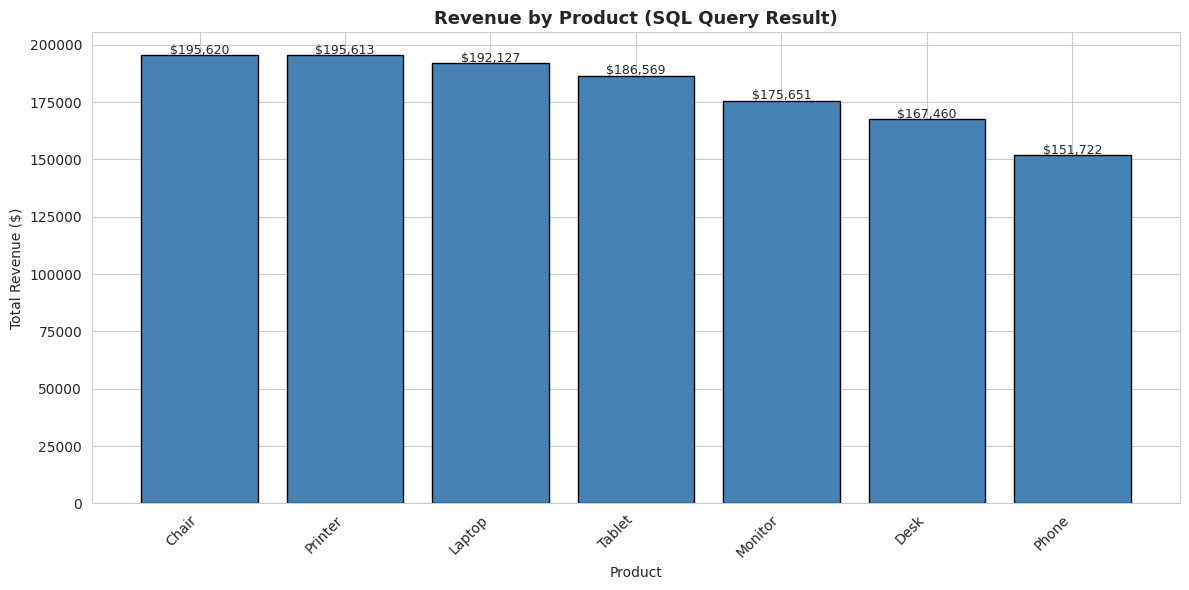

 Chart saved!


In [ ]:

print('QUERY 5: GROUP BY - Revenue by Product')


query5 = """
SELECT
    Product,
    COUNT(*)                      AS Total_Orders,
    ROUND(SUM(TotalPrice), 2)     AS Total_Revenue,
    ROUND(AVG(TotalPrice), 2)     AS Avg_Order_Value,
    ROUND(MIN(TotalPrice), 2)     AS Min_Order,
    ROUND(MAX(TotalPrice), 2)     AS Max_Order
FROM orders
GROUP BY Product
ORDER BY Total_Revenue DESC;
"""

print('SQL Query:')
print(query5)
print('Results:')
result5 = run_sql(query5, show_rows=20)

print('\n Business Insight:')
print('   This single query replaces hours of Excel work!')
print('   Now we know EXACTLY which product generates most revenue')

# Visualize it
plt.figure(figsize=(12, 6))
plt.bar(result5['Product'], result5['Total_Revenue'], color='steelblue', edgecolor='black')
plt.title('Revenue by Product (SQL Query Result)', fontsize=13, fontweight='bold')
plt.xlabel('Product')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(result5['Total_Revenue']):
    plt.text(i, v + 500, f'${v:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('sql_revenue_by_product.png', dpi=100)
plt.show()
print(' Chart saved!')

# QUERY 6: GROUP BY - Payment Method Analysis

In [ ]:

print('QUERY 6: Payment Method Analysis')


query6 = """
SELECT
    PaymentMethod,
    COUNT(*)                       AS Total_Orders,
    ROUND(SUM(TotalPrice), 2)      AS Total_Revenue,
    ROUND(AVG(TotalPrice), 2)      AS Avg_Order_Value,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders), 2) AS Pct_Of_Orders
FROM orders
GROUP BY PaymentMethod
ORDER BY Total_Orders DESC;
"""

print('SQL Query:')
print(query6)
print('Results:')
result6 = run_sql(query6)

print('\n Business Insight:')
print('   Pct_Of_Orders = percentage formula using a subquery!')
print('   This tells us customer payment preferences')
print('   High concentration in one method = business risk')

QUERY 6: Payment Method Analysis
SQL Query:

SELECT 
    PaymentMethod,
    COUNT(*)                       AS Total_Orders,
    ROUND(SUM(TotalPrice), 2)      AS Total_Revenue,
    ROUND(AVG(TotalPrice), 2)      AS Avg_Order_Value,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders), 2) AS Pct_Of_Orders
FROM orders
GROUP BY PaymentMethod
ORDER BY Total_Orders DESC;

Results:

Rows returned: 5
PaymentMethod  Total_Orders  Total_Revenue  Avg_Order_Value  Pct_Of_Orders
       Online           258      262442.94          1017.22          21.50
         Cash           246      259786.29          1056.04          20.50
  Credit Card           234      263847.63          1127.55          19.50
   Debit Card           232      232361.18          1001.56          19.33
    Gift Card           230      246323.92          1070.97          19.17

 Business Insight:
   Pct_Of_Orders = percentage formula using a subquery!
   This tells us customer payment preferences
   High concentration in 


#  QUERY 7: ORDER BY - Top 10 Orders

In [ ]:

print('QUERY 7: ORDER BY - Top 10 Highest Value Orders')


query7 = """
SELECT
    OrderID,
    Date,
    Product,
    Quantity,
    ROUND(UnitPrice, 2)   AS Unit_Price,
    ROUND(TotalPrice, 2)  AS Total_Price,
    PaymentMethod,
    OrderStatus
FROM orders
ORDER BY TotalPrice DESC
LIMIT 10;
"""

print('SQL Query:')
print(query7)
print('Results (Top 10 Biggest Orders):')
result7 = run_sql(query7, show_rows=10)

print('\n Business Insight:')
print('   These 10 orders are your most valuable transactions')
print('   Study them: What product? What payment? What status?')
print('   This is how you identify VIP customer patterns!')

QUERY 7: ORDER BY - Top 10 Highest Value Orders
SQL Query:

SELECT 
    OrderID,
    Date,
    Product,
    Quantity,
    ROUND(UnitPrice, 2)   AS Unit_Price,
    ROUND(TotalPrice, 2)  AS Total_Price,
    PaymentMethod,
    OrderStatus
FROM orders
ORDER BY TotalPrice DESC
LIMIT 10;

Results (Top 10 Biggest Orders):

Rows returned: 10
  OrderID       Date Product  Quantity  Unit_Price  Total_Price PaymentMethod OrderStatus
ORD200789 2023-08-17  Tablet         5      691.28      3456.40        Online   Delivered
ORD201122 2023-06-07 Monitor         5      678.19      3390.95        Online    Returned
ORD200632 2023-05-02  Laptop         5      678.16      3390.80     Gift Card   Delivered
ORD200469 2023-11-26   Chair         5      676.98      3384.90          Cash   Cancelled
ORD200328 2023-02-28  Tablet         5      674.04      3370.20        Online   Cancelled
ORD200107 2023-03-27 Printer         5      670.75      3353.75     Gift Card     Shipped
ORD200326 2024-07-01  Laptop      

#  QUERY 8: WHERE + GROUP BY Combined

In [ ]:

print('QUERY 8: WHERE + GROUP BY - Completed Orders by Product')


# First check what order statuses exist
status_check = pd.read_sql_query(
    "SELECT DISTINCT OrderStatus FROM orders", conn)
print(f'Available statuses: {status_check["OrderStatus"].tolist()}')
top_status = status_check['OrderStatus'].values[0]

query8 = f"""
SELECT
    Product,
    COUNT(*)                    AS Order_Count,
    ROUND(SUM(TotalPrice), 2)   AS Revenue,
    ROUND(AVG(TotalPrice), 2)   AS Avg_Value
FROM orders
WHERE OrderStatus = '{top_status}'
GROUP BY Product
ORDER BY Revenue DESC;
"""

print(f'\nSQL Query (filtering for "{top_status}" status):')
print(query8)
print('Results:')
result8 = run_sql(query8)

print('\n Business Insight:')
print(f'   Only counting "{top_status}" orders removes noise')
print('   WHERE runs BEFORE GROUP BY in SQL execution order')
print('   This gives us TRUE completed revenue by product')

QUERY 8: WHERE + GROUP BY - Completed Orders by Product
Available statuses: ['Shipped', 'Cancelled', 'Returned', 'Delivered', 'Pending']

SQL Query (filtering for "Shipped" status):

SELECT 
    Product,
    COUNT(*)                    AS Order_Count,
    ROUND(SUM(TotalPrice), 2)   AS Revenue,
    ROUND(AVG(TotalPrice), 2)   AS Avg_Value
FROM orders
WHERE OrderStatus = 'Shipped'
GROUP BY Product
ORDER BY Revenue DESC;

Results:

Rows returned: 7
Product  Order_Count  Revenue  Avg_Value
Printer           42 44397.41    1057.08
  Chair           31 40350.44    1301.63
 Laptop           29 40237.23    1387.49
 Tablet           40 34828.15     870.70
   Desk           33 33424.89    1012.88
Monitor           32 30924.82     966.40
  Phone           28 21996.64     785.59

 Business Insight:
   Only counting "Shipped" orders removes noise
   WHERE runs BEFORE GROUP BY in SQL execution order
   This gives us TRUE completed revenue by product


#  QUERY 9: HAVING - Filter After Grouping

In [ ]:

print('QUERY 9: HAVING - Products with significant sales volume')


query9 = """
SELECT
    Product,
    COUNT(*)                    AS Order_Count,
    ROUND(SUM(TotalPrice), 2)   AS Total_Revenue,
    ROUND(AVG(TotalPrice), 2)   AS Avg_Order_Value
FROM orders
GROUP BY Product
HAVING COUNT(*) > 100
ORDER BY Order_Count DESC;
"""

print('SQL Query:')
print(query9)
print('Results (Products with >100 orders):')
result9 = run_sql(query9)

print('\n Business Insight:')
print('   HAVING filters AFTER grouping (WHERE cannot do this!)')
print('   Only shows products with substantial order volume')
print('   These are your CORE products - must never run out of stock!')

QUERY 9: HAVING - Products with significant sales volume
SQL Query:

SELECT 
    Product,
    COUNT(*)                    AS Order_Count,
    ROUND(SUM(TotalPrice), 2)   AS Total_Revenue,
    ROUND(AVG(TotalPrice), 2)   AS Avg_Order_Value
FROM orders
GROUP BY Product
HAVING COUNT(*) > 100
ORDER BY Order_Count DESC;

Results (Products with >100 orders):

Rows returned: 7
Product  Order_Count  Total_Revenue  Avg_Order_Value
Printer          181      195612.61          1080.73
 Tablet          179      186568.95          1042.28
  Chair          178      195620.11          1098.99
 Laptop          173      192126.56          1110.56
   Desk          170      167459.93           985.06
Monitor          163      175651.41          1077.62
  Phone          156      151722.39           972.58

 Business Insight:
   HAVING filters AFTER grouping (WHERE cannot do this!)
   Only shows products with substantial order volume
   These are your CORE products - must never run out of stock!


#  QUERY 10: Date-Based Trend Analysis

QUERY 10: Monthly Revenue Trend
SQL Query:

SELECT 
    SUBSTR(Date, 1, 7)              AS Year_Month,
    COUNT(*)                        AS Total_Orders,
    ROUND(SUM(TotalPrice), 2)       AS Monthly_Revenue,
    ROUND(AVG(TotalPrice), 2)       AS Avg_Order_Value,
    ROUND(SUM(Quantity), 0)         AS Total_Items_Sold
FROM orders
GROUP BY SUBSTR(Date, 1, 7)
ORDER BY Year_Month ASC;

Results:

Rows returned: 30
Year_Month  Total_Orders  Monthly_Revenue  Avg_Order_Value  Total_Items_Sold
   2023-01            47         56685.75          1206.08             146.0
   2023-02            37         40117.66          1084.26             102.0
   2023-03            43         48609.37          1130.45             126.0
   2023-04            31         27751.71           895.22              84.0
   2023-05            49         63836.84          1302.79             148.0
   2023-06            45         49500.19          1100.00             146.0
   2023-07            44         42820.66  

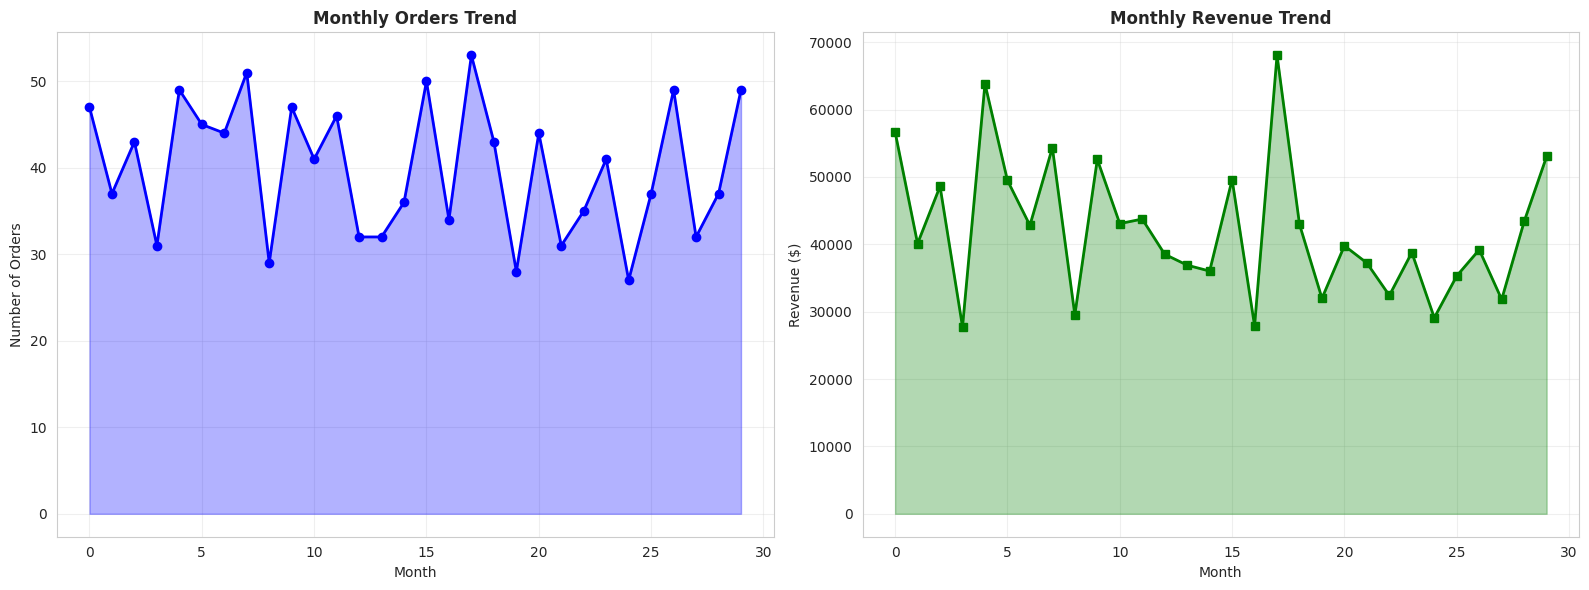

 Chart saved!

 Business Insight:
   SUBSTR(Date, 1, 7) extracts YYYY-MM from the date
   This shows seasonal patterns and growth trends
   Use this to plan inventory and staffing!


In [ ]:

print('QUERY 10: Monthly Revenue Trend')


query10 = """
SELECT
    SUBSTR(Date, 1, 7)              AS Year_Month,
    COUNT(*)                        AS Total_Orders,
    ROUND(SUM(TotalPrice), 2)       AS Monthly_Revenue,
    ROUND(AVG(TotalPrice), 2)       AS Avg_Order_Value,
    ROUND(SUM(Quantity), 0)         AS Total_Items_Sold
FROM orders
GROUP BY SUBSTR(Date, 1, 7)
ORDER BY Year_Month ASC;
"""

print('SQL Query:')
print(query10)
print('Results:')
result10 = run_sql(query10, show_rows=20)

# Visualize monthly trend
if len(result10) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    months = range(len(result10))
    axes[0].plot(months, result10['Total_Orders'], marker='o',
                 linewidth=2, color='blue', markersize=6)
    axes[0].fill_between(months, result10['Total_Orders'], alpha=0.3, color='blue')
    axes[0].set_title('Monthly Orders Trend', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Month')
    axes[0].set_ylabel('Number of Orders')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(months, result10['Monthly_Revenue'], marker='s',
                 linewidth=2, color='green', markersize=6)
    axes[1].fill_between(months, result10['Monthly_Revenue'], alpha=0.3, color='green')
    axes[1].set_title('Monthly Revenue Trend', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Revenue ($)')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('sql_monthly_trend.png', dpi=100)
    plt.show()
    print(' Chart saved!')

print('\n Business Insight:')
print('   SUBSTR(Date, 1, 7) extracts YYYY-MM from the date')
print('   This shows seasonal patterns and growth trends')
print('   Use this to plan inventory and staffing!')

#  QUERY 11: Referral Source Performance

In [ ]:

print('QUERY 11: Referral Source Performance')


query11 = """
SELECT
    ReferralSource,
    COUNT(*)                                                    AS Total_Orders,
    ROUND(SUM(TotalPrice), 2)                                   AS Total_Revenue,
    ROUND(AVG(TotalPrice), 2)                                   AS Avg_Order_Value,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders), 1) AS Pct_Share
FROM orders
GROUP BY ReferralSource
ORDER BY Total_Revenue DESC;
"""

print('SQL Query:')
print(query11)
print('Results:')
result11 = run_sql(query11)

print('\n Business Insight:')
print('   This shows ROI of each marketing channel')
print('   High orders + high avg value = best channel to invest in')
print('   Used by marketing teams to allocate budget!')

QUERY 11: Referral Source Performance
SQL Query:

SELECT 
    ReferralSource,
    COUNT(*)                                                    AS Total_Orders,
    ROUND(SUM(TotalPrice), 2)                                   AS Total_Revenue,
    ROUND(AVG(TotalPrice), 2)                                   AS Avg_Order_Value,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders), 1) AS Pct_Share
FROM orders
GROUP BY ReferralSource
ORDER BY Total_Revenue DESC;

Results:

Rows returned: 5
ReferralSource  Total_Orders  Total_Revenue  Avg_Order_Value  Pct_Share
     Instagram           259      275285.45          1062.88       21.6
         Email           250      261808.55          1047.23       20.8
        Google           241      250441.48          1039.18       20.1
      Facebook           228      250410.90          1098.29       19.0
      Referral           222      226815.58          1021.69       18.5

 Business Insight:
   This shows ROI of each marketing channel
   High or

#  QUERY 12: Executive Summary Query

In [ ]:

print('QUERY 12: Complete Business Summary')

query12 = """
SELECT
    COUNT(*)                        AS Total_Orders,
    COUNT(DISTINCT Product)         AS Unique_Products,
    COUNT(DISTINCT PaymentMethod)   AS Payment_Methods,
    COUNT(DISTINCT ReferralSource)  AS Marketing_Channels,
    ROUND(SUM(TotalPrice), 2)       AS Total_Revenue,
    ROUND(AVG(TotalPrice), 2)       AS Avg_Order_Value,
    ROUND(MIN(TotalPrice), 2)       AS Smallest_Order,
    ROUND(MAX(TotalPrice), 2)       AS Largest_Order,
    ROUND(SUM(Quantity), 0)         AS Total_Items_Sold,
    ROUND(AVG(Quantity), 2)         AS Avg_Items_Per_Order
FROM orders;
"""

print('SQL Query:')
print(query12)
print('Results:')
result12 = run_sql(query12)



QUERY 12: Complete Business Summary
SQL Query:

SELECT
    COUNT(*)                        AS Total_Orders,
    COUNT(DISTINCT Product)         AS Unique_Products,
    COUNT(DISTINCT PaymentMethod)   AS Payment_Methods,
    COUNT(DISTINCT ReferralSource)  AS Marketing_Channels,
    ROUND(SUM(TotalPrice), 2)       AS Total_Revenue,
    ROUND(AVG(TotalPrice), 2)       AS Avg_Order_Value,
    ROUND(MIN(TotalPrice), 2)       AS Smallest_Order,
    ROUND(MAX(TotalPrice), 2)       AS Largest_Order,
    ROUND(SUM(Quantity), 0)         AS Total_Items_Sold,
    ROUND(AVG(Quantity), 2)         AS Avg_Items_Per_Order
FROM orders;

Results:

Rows returned: 1
 Total_Orders  Unique_Products  Payment_Methods  Marketing_Channels  Total_Revenue  Avg_Order_Value  Smallest_Order  Largest_Order  Total_Items_Sold  Avg_Items_Per_Order
         1200                7                5                   5     1264761.96          1053.97           11.39         3456.4            3535.0                 2.95


#  SQL ANALYSIS REPORT

In [ ]:
# Get values for report
summary = pd.read_sql_query(query12, conn).iloc[0]
top_product = pd.read_sql_query(
    "SELECT Product, SUM(TotalPrice) as rev FROM orders GROUP BY Product ORDER BY rev DESC LIMIT 1", conn)
top_source = pd.read_sql_query(
    "SELECT ReferralSource, COUNT(*) as cnt FROM orders GROUP BY ReferralSource ORDER BY cnt DESC LIMIT 1", conn)
top_payment = pd.read_sql_query(
    "SELECT PaymentMethod, COUNT(*) as cnt FROM orders GROUP BY PaymentMethod ORDER BY cnt DESC LIMIT 1", conn)

report = f"""
SQL DATA ANALYSIS REPORT
DecodeLabs Internship - Project 3


BUSINESS OVERVIEW (Query 12)
  Total Orders        : {int(summary['Total_Orders']):,}
  Total Revenue       : ${float(summary['Total_Revenue']):,.2f}
  Avg Order Value     : ${float(summary['Avg_Order_Value']):,.2f}
  Smallest Order      : ${float(summary['Smallest_Order']):,.2f}
  Largest Order       : ${float(summary['Largest_Order']):,.2f}
  Total Items Sold    : {int(summary['Total_Items_Sold']):,}
  Unique Products     : {int(summary['Unique_Products'])}
  Payment Methods     : {int(summary['Payment_Methods'])}
  Marketing Channels  : {int(summary['Marketing_Channels'])}

KEY SQL FINDINGS
  Top Product         : {top_product['Product'].values[0]} (${float(top_product['rev'].values[0]):,.2f})
  Top Referral Source : {top_source['ReferralSource'].values[0]} ({int(top_source['cnt'].values[0])} orders)
  Top Payment Method  : {top_payment['PaymentMethod'].values[0]} ({int(top_payment['cnt'].values[0])} orders)

SQL TECHNIQUES DEMONSTRATED
  Query 1  : SELECT * (Basic data retrieval)
  Query 2  : COUNT, DISTINCT (Volume metrics)
  Query 3  : SUM, AVG, MIN, MAX, ROUND (Financial metrics)
  Query 4  : WHERE (Row filtering)
  Query 5  : GROUP BY + aggregations (Product analysis)
  Query 6  : Subquery for percentage calculation
  Query 7  : ORDER BY DESC + LIMIT (Top-N ranking)
  Query 8  : WHERE + GROUP BY combined
  Query 9  : HAVING (Post-aggregation filtering)
  Query 10 : SUBSTR for date grouping
  Query 11 : Multi-metric channel analysis
  Query 12 : Executive summary dashboard

BUSINESS RECOMMENDATIONS
  1. Focus inventory on top-performing products
  2. Invest marketing budget in best referral channels
  3. Monitor high-value orders for VIP customer patterns
  4. Ensure payment method diversity to reduce risk
  5. Use monthly trends for seasonal planning


PROJECT 3 COMPLETE - SQL Analysis Done!

"""

print(report)

with open('SQL_ANALYSIS_REPORT.txt', 'w') as f:
    f.write(report)

print(' Report saved: SQL_ANALYSIS_REPORT.txt')


SQL DATA ANALYSIS REPORT
DecodeLabs Internship - Project 3


BUSINESS OVERVIEW (Query 12)
  Total Orders        : 1,200
  Total Revenue       : $1,264,761.96
  Avg Order Value     : $1,053.97
  Smallest Order      : $11.39
  Largest Order       : $3,456.40
  Total Items Sold    : 3,535
  Unique Products     : 7
  Payment Methods     : 5
  Marketing Channels  : 5

KEY SQL FINDINGS
  Top Product         : Chair ($195,620.11)
  Top Referral Source : Instagram (259 orders)
  Top Payment Method  : Online (258 orders)

SQL TECHNIQUES DEMONSTRATED
  Query 1  : SELECT * (Basic data retrieval)
  Query 2  : COUNT, DISTINCT (Volume metrics)
  Query 3  : SUM, AVG, MIN, MAX, ROUND (Financial metrics)
  Query 4  : WHERE (Row filtering)
  Query 5  : GROUP BY + aggregations (Product analysis)
  Query 6  : Subquery for percentage calculation
  Query 7  : ORDER BY DESC + LIMIT (Top-N ranking)
  Query 8  : WHERE + GROUP BY combined
  Query 9  : HAVING (Post-aggregation filtering)
  Query 10 : SUBSTR for

In [ ]:
# Download all files
from google.colab import files

print(' Downloading all outputs...')
files.download('SQL_ANALYSIS_REPORT.txt')
files.download('sql_revenue_by_product.png')
files.download('sql_monthly_trend.png')

conn.close()
print('\n All files downloaded!')
print(' Database connection closed!')
